In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from datasets import load_dataset
from typing import List
import re

from natasha import (
    Segmenter,
    MorphVocab,
    NewsMorphTagger,
    NewsSyntaxParser,
    NewsEmbedding,
    Doc
)
from pymorphy3 import MorphAnalyzer

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter

In [3]:
df = load_dataset("ai-forever/kinopoisk-sentiment-classification")
df = df["train"].to_pandas()

In [4]:
df = df.drop(["id"], axis=1)

In [101]:
labels = df["label"]
dfN = df["text"][:5001]

In [102]:
df["text"][0]

'Если честно, меня не очень впечатлила новость, о том, что Гай Ричи собирается снять фильм, о Шерлоке Холмсе. Подумал — да это же будет: Карты, деньги, два ствола — у Холмса и у Ватсона. Но затем по мере появления трейлеров, и большей информации поменял своё отношение.\n«Шерлок Холмс» — последняя картина, на которую я планировал пойти в этом году. Жутко боялся, что она меня разочарует т. к. перед этим были расстроившие «Безумный спецназ», «Так себе каникулы» и немного 2012. Но Холмс полностью оправдал доверия.\nСюжет\nВ ленте динамичный, а главное интересный и захватывающий сюжет, что в последнее время не так уж и часто. Новый Холмс не поход классический образ представленный в картинах Игоря Масленникова, но это не портит его образ. Он больше подобен на Тони Старку из «Железного человека» или Грегори Хаусу из сериала «Доктор Хаус». Как и они, он весьма харизматичен, слегка безумен, но гениален в своём любимом деле.\nНа первый взгляд сюжет портит сверхъестественное восстание из могилы л

In [103]:
text = dfN.to_numpy()

In [104]:
text.shape

(5001,)

## Work

In [105]:
seg = Segmenter() # делит текст на предложения и слова (токенс)
emb = NewsEmbedding() # векторное представление слов
morph_tagger = NewsMorphTagger(emb) # определение частей речи и грамматики (морф. анализ)
syntax_parser = NewsSyntaxParser(emb) # синт разбор (дерево решений)

morph_lemm = MorphVocab() #  lemm

In [106]:
def cls_text(doc: str) -> str:
    doc = doc.replace("\n", " ")

    return doc

In [107]:
def load_texts(doc: str, morph: MorphAnalyzer) -> List:
    """
    Загружает предложения из документа 
    """

    docl = Doc(cls_text(doc))
    docl.segment(seg)

    arr_sent = [sent.text.strip() for sent in docl.sents]
    
    return arr_sent

In [108]:
docSentN = []

for doc in dfN:
    sentences = load_texts(doc, morph)
    docSentN.extend(sentences)

In [109]:
print(f"Загружено предложений: {len(docSentN)}")

Загружено предложений: 107636


In [110]:
def parse_sentence(sentence, segmenter, morph_tagger, syntax_parser, morph_lemm):
    doc = Doc(sentence)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    doc.parse_syntax(syntax_parser)

    if not doc.sents:
        return None, None
    
    sent = doc.sents[0]
    tokens = list(sent.tokens)

    subject = None
    predicate = None

    for token in tokens:
        if token.rel in ["nsubj", "nsubj:pass"]:
            token.lemmatize(morph_lemm)
            subject = token.lemma.lower()

    for token in tokens:
        if token.rel == "root":
            token.lemmatize(morph_lemm)
            predicate = token.lemma.lower()

    return subject, predicate

In [111]:
docSentN[25:35]

['P.S. Жду продолжения и обязательно от Гая Ричи…',
 'Сразу скажу — книгу я не читала, поэтому о том, что все это должно было бы значить, не в курсе.',
 'Фильм я смотрела по совету знакомой, которая порекомендовала мне его в «догонку» после «Острова проклятых».',
 'И сейчас, спустя два часа невыносимой скуки, остается один вопрос — а о чем кино вообще было?',
 'И за что столько Оскаров?',
 'Ибо фильм от начала до конца — бессмысленная тягомотина.',
 'Нам показывают парня, который, изнасиловав 15-летнюю девочку (уже один этот факт вызвал у меня отвращение к главному герою) и натворив еще Бог знает чего попадает в психушку, где якобы устравивает «бунт против системы».',
 'Далее по аннотации перед нами должны предстать запуганные, забитые люди, признающие себя психами из боязни что-то изменить, и деспотичные медработники, издевающиеся над пациентами…',
 'Стоп-стоп, может, я не тот фильм смотрела?',
 'По-моему, люди эти сидят в больнице вполне себе заслуженно…']

In [112]:
for sentence in docSentN[25:35]:
    print(parse_sentence(sentence, seg, morph_tagger, syntax_parser, morph_lemm))

(None, 'ждать')
('это', 'сказать')
('который', 'смотреть')
('кино', 'оставаться')
(None, None)
('фильм', 'тягомотина')
('бог', 'показывать')
('запуганный', 'должный')
('я', 'смотреть')
('человек', 'сидеть')


In [113]:
def build_cooccurrence_dependencies(texts: List[str], segmenter, morph_tagger, syntax_parser):
    """
    Строит зависимости совместных употреблений подлежащих и сказуемых.
    """

    cooccurrences = []
    
    for sentence in texts:
        # Парсим подлежащее и сказуемое
        subject, predicate = parse_sentence(sentence, segmenter, morph_tagger, syntax_parser, morph_lemm)
        
        if subject and predicate:
            cooccurrences.append((subject, predicate))
    
    # Подсчитываем частоты
    counter = Counter(cooccurrences)
    
    return counter


In [114]:
def visualize_results(counter: Counter, top_n: int = 20):
    top_pairs = counter.most_common(top_n)
    
    df_plot = pd.DataFrame(top_pairs, columns=['pair', 'count'])
    df_plot['pair_str'] = df_plot['pair'].apply(lambda x: f"{x[0]}-{x[1]}")
    df_plot['subject'] = df_plot['pair'].apply(lambda x: x[0])
    df_plot['predicate'] = df_plot['pair'].apply(lambda x: x[1])
    
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")
    
    sns.barplot(data=df_plot, y='pair_str', x='count', palette='viridis')
    
    plt.title(f'Топ-{top_n} сочетаний подлежащее-глагол', fontsize=16, fontweight='bold')
    plt.xlabel('Частота встречаемости', fontsize=12)
    plt.ylabel('Подлежащее - Глагол', fontsize=12)
    plt.tight_layout()
    
    for i, v in enumerate(df_plot['count']):
        plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')
    
    plt.show()

In [115]:
cooc = build_cooccurrence_dependencies(docSentN, seg, morph_tagger, syntax_parser)

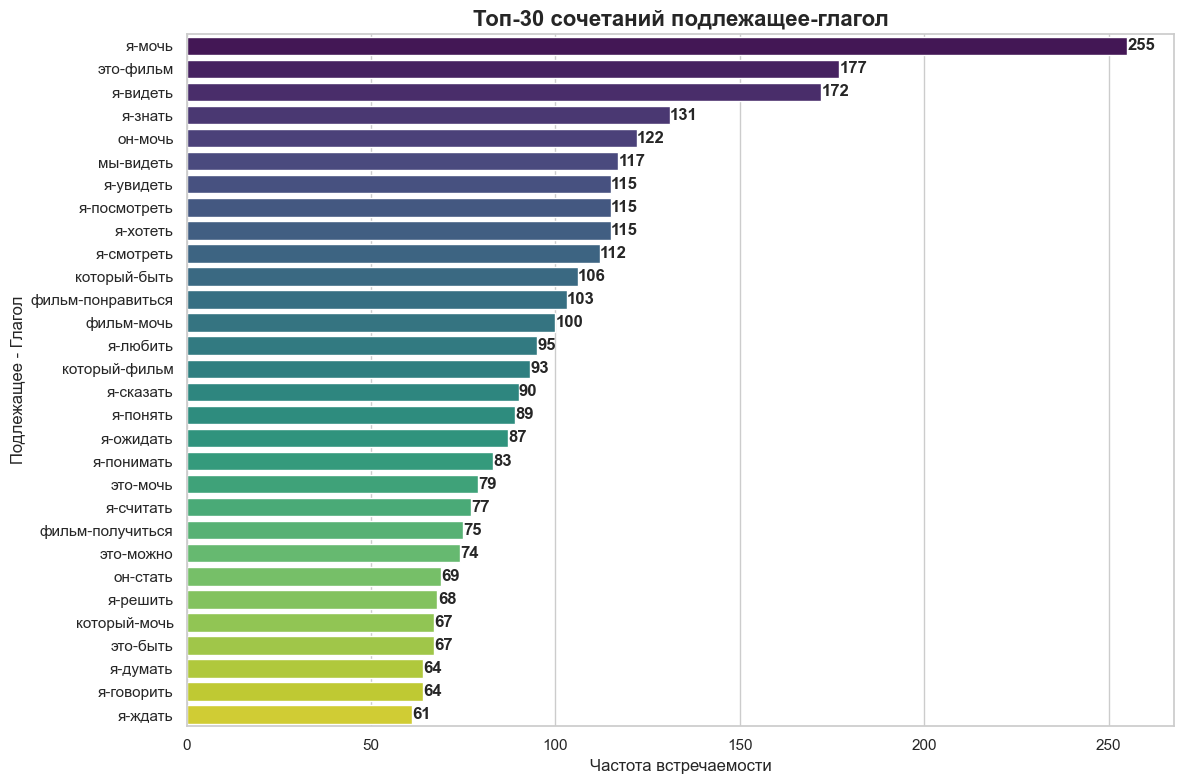

In [116]:
visualize_results(cooc, 30)